In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MACHINE = "RoboticArm"

DATA_ROOT = Path("data/RoboticArm")

TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

parametry techniczne sensorów wykorzystanych do zgromadzenia danych:
 - imp23absu_mic: Mikrofon analogowy z częstotliwością próbkowania 16kHz

 - ism330dhcx_acc: Akcelerometr - rejestruje drgania w 3 osiach (X, Y, Z) z częstotliwością 6.7kHz
 
 - ism330dhcx_gyro: Żyroskop – mierzy prędkość kątową w 3 osiach (X, Y, Z) z częstotliwością 6.7kHz


In [ ]:
normal_source_train = pd.read_csv(TRAIN_DIR / "attributes_normal_source_train.csv")
normal_target_train = pd.read_csv(TRAIN_DIR / "attributes_normal_target_train.csv")

normal_source_test = pd.read_csv(TEST_DIR / "attributes_normal_source_test.csv")
anomaly_source_test = pd.read_csv(TEST_DIR / "attributes_anomaly_source_test.csv")
normal_target_test = pd.read_csv(TEST_DIR / "attributes_normal_target_test.csv")
anomaly_target_test = pd.read_csv(TEST_DIR / "attributes_anomaly_target_test.csv")


In [ ]:
train_metadata = pd.concat([normal_source_train, normal_target_train], ignore_index=True)

test_metadata = pd.concat([normal_source_test, anomaly_source_test, normal_target_test, anomaly_target_test], ignore_index=True) 

In [35]:
print("Train:", train_metadata.shape)
print("Test :", test_metadata.shape)

Train: (1839, 8)
Test : (464, 8)


Mamy podzielony zbiór danych na treningowy i testowy

Każda próbka jest opisana przez 8 kolumn z metadanymi

In [36]:
print("TRAIN")
display(train_metadata.head())

print("TEST")
display(test_metadata.head())

TRAIN


,segment_id,split_label,anomaly_label,domain_shift_op,domain_shift_env,imp23absu_mic,ism330dhcx_acc,ism330dhcx_gyro
0,20240418_14_01_48_dataLog_12,Normal_Source_Train,normal,weight00,BckgF,imp23absu_mic_20240418_14_01_48_dataLog_12.par...,ism330dhcx_acc_20240418_14_01_48_dataLog_12.pa...,ism330dhcx_gyro_20240418_14_01_48_dataLog_12.p...
1,20240418_10_16_44_dataLog_12,Normal_Source_Train,normal,weight15,BckgC,imp23absu_mic_20240418_10_16_44_dataLog_12.par...,ism330dhcx_acc_20240418_10_16_44_dataLog_12.pa...,ism330dhcx_gyro_20240418_10_16_44_dataLog_12.p...
2,20240222_13_46_29_dataLog_26,Normal_Source_Train,normal,weight20,BckgD,imp23absu_mic_20240222_13_46_29_dataLog_26.par...,ism330dhcx_acc_20240222_13_46_29_dataLog_26.pa...,ism330dhcx_gyro_20240222_13_46_29_dataLog_26.p...
3,20240221_14_11_25_dataLog_10,Normal_Source_Train,normal,weight10,BckgA,imp23absu_mic_20240221_14_11_25_dataLog_10.par...,ism330dhcx_acc_20240221_14_11_25_dataLog_10.pa...,ism330dhcx_gyro_20240221_14_11_25_dataLog_10.p...
4,20240405_15_09_59_dataLog_22,Normal_Source_Train,normal,weight15,BckgD,imp23absu_mic_20240405_15_09_59_dataLog_22.par...,ism330dhcx_acc_20240405_15_09_59_dataLog_22.pa...,ism330dhcx_gyro_20240405_15_09_59_dataLog_22.p...


TEST


,segment_id,split_label,anomaly_label,domain_shift_op,domain_shift_env,imp23absu_mic,ism330dhcx_acc,ism330dhcx_gyro
0,20240221_13_21_57_dataLog_7,Normal_Source_Test,normal,weight10,BckgA,imp23absu_mic_20240221_13_21_57_dataLog_7.parquet,ism330dhcx_acc_20240221_13_21_57_dataLog_7.par...,ism330dhcx_gyro_20240221_13_21_57_dataLog_7.pa...
1,20240221_13_05_28_dataLog_25,Normal_Source_Test,normal,weight10,BckgC,imp23absu_mic_20240221_13_05_28_dataLog_25.par...,ism330dhcx_acc_20240221_13_05_28_dataLog_25.pa...,ism330dhcx_gyro_20240221_13_05_28_dataLog_25.p...
2,20240405_10_45_40_dataLog_19,Normal_Source_Test,normal,weight15,BckgC,imp23absu_mic_20240405_10_45_40_dataLog_19.par...,ism330dhcx_acc_20240405_10_45_40_dataLog_19.pa...,ism330dhcx_gyro_20240405_10_45_40_dataLog_19.p...
3,20240405_10_45_40_dataLog_18,Normal_Source_Test,normal,weight15,BckgF,imp23absu_mic_20240405_10_45_40_dataLog_18.par...,ism330dhcx_acc_20240405_10_45_40_dataLog_18.pa...,ism330dhcx_gyro_20240405_10_45_40_dataLog_18.p...
4,20240222_14_44_09_dataLog_31,Normal_Source_Test,normal,weight20,BckgD,imp23absu_mic_20240222_14_44_09_dataLog_31.par...,ism330dhcx_acc_20240222_14_44_09_dataLog_31.pa...,ism330dhcx_gyro_20240222_14_44_09_dataLog_31.p...


In [37]:
print("Train columns:")
print(train_metadata.columns.tolist())

print("Test columns:")
print(test_metadata.columns.tolist())

Train columns:
['segment_id', 'split_label', 'anomaly_label', 'domain_shift_op', 'domain_shift_env', 'imp23absu_mic', 'ism330dhcx_acc', 'ism330dhcx_gyro']
Test columns:
['segment_id', 'split_label', 'anomaly_label', 'domain_shift_op', 'domain_shift_env', 'imp23absu_mic', 'ism330dhcx_acc', 'ism330dhcx_gyro']


In [38]:
print("Train:")
print(train_metadata["split_label"].value_counts())

print("Test:")
print(test_metadata["split_label"].value_counts())

Train:
split_label
Normal_Source_Train    1812
Normal_Target_Train      27
Name: count, dtype: int64
Test:
split_label
Normal_Source_Test     116
Anomaly_Source_Test    116
Normal_Target_Test     116
Anomaly_Target_Test    116
Name: count, dtype: int64


Zbiór treningowy zawiera wyłącznie dane ze stanu prawidłowej pracy ramienia (Normal) z czego 1812 obserwacji pochodzi z domeny źródłowej (Source), a 27 obserwacji z domeny Target.

W zbiorze testowym (test) znajdują się nagrania z domeny Source oraz Target w stanie Normal i Anomaly.
Zbiór testowy mamy podzielony po równo na 4 grupy: Normal Source, Anomaly Source, Normal Target, Anomaly Target, to znaczy że 50% próbek w zbiorze testowym to normalne zachowanie maszyny, a 50% to anomalie. Jednocześnie połowa próbek pochodzi z domeny Source, a połowa z domeny Target.

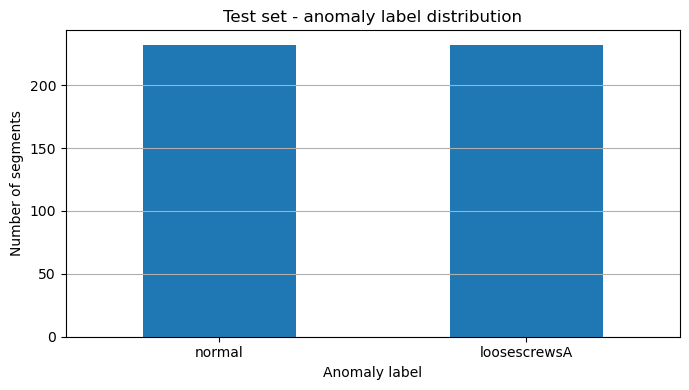

In [40]:
plt.figure(figsize=(7, 4))

test_metadata["anomaly_label"].value_counts().plot(kind="bar")

plt.title("Test set - anomaly label distribution")
plt.xlabel("Anomaly label")
plt.ylabel("Number of segments")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Wykres ponownie wizualizuje to, co wyszło wcześniej, zbiór testowy pod kątem detekcji awarii jest zbalansowany 50/50 między stanem prawidłowym (normal) a anomalią (loosescrewsA).

zliczmy liczbę próbek testowych dla każdego z poziomów obciążeń operacyjnych z podziałem na stan maszyny (normalna czy anomalia)

In [13]:
pd.crosstab(test_metadata["domain_shift_op"], test_metadata["anomaly_label"])

anomaly_label,loosescrewsA,normal
domain_shift_op,,
weight00,29,29
weight10,28,28
weight15,29,29
weight20,30,30
weight25,39,39
weight30,38,38
weight35,39,39


widzimy, że dla każdego obciążenia liczba próbek z anomalią jest dokładnie równa liczbie próbek prawidłowych 

zliczamy próbki w zbiorze testowym w rozbiciu na rodzaje szumów tła (BckgA do BckgG) oraz odpowiadające im etykiety awarii (loosescrewsA i normal)

In [14]:
pd.crosstab(test_metadata["domain_shift_env"], test_metadata["anomaly_label"])

anomaly_label,loosescrewsA,normal
domain_shift_env,,
BckgA,30,30
BckgB,39,39
BckgC,30,30
BckgD,28,28
BckgE,39,39
BckgF,28,28
BckgG,38,38


ponownie widzimy, że liczba próbek z anomalią jest dokładnie równa liczbie próbek prawidłowych (50/50) dla każdego wariantu tła szumowego.


w zbiorze testowym zarówno dla każdego poziomu obciążenia maszyny, jak i szumów tła obserwacje zawierają dokładnie po połowie próbek normalnych i z anomalią

In [ ]:
# pomocnicza funkcja do wczytywania danych z sensora dla danego segmentu
def load_sensor(segment_id, sensor, data_dir):
    sensor_prefix = {
        "acc": "ism330dhcx_acc",
        "gyro": "ism330dhcx_gyro",
        "mic": "imp23absu_mic"
    }
    prefix = sensor_prefix[sensor]
    file_path = data_dir / f"{prefix}_{segment_id}.parquet"
    if not file_path.exists():
        raise FileNotFoundError(
            f"Nie znaleziono pliku: {file_path}"
        )
    return pd.read_parquet(file_path)

# funkcja do wczytywania wszystkich 3 sensorów dla danego segmentu 
def load_sensor_segment(segment_id, data_dir):
    acc = load_sensor(segment_id, "acc", data_dir)
    gyro = load_sensor(segment_id, "gyro", data_dir)
    mic = load_sensor(segment_id, "mic", data_dir)    
    return acc, gyro, mic

wczytajmy przykładowy segment danych z zestawu testowego, aby zobaczyć jak wyglądają dane z poszczególnych sensorów

In [19]:
segment_id = "20240221_11_10_55_dataLog_10"
# wczytuje segment danych o nazwie "20240221_11_10_55_dataLog_10" z zestawu testowego
acc, gyro, mic = load_sensor_segment(segment_id, TEST_DIR)

In [20]:
print("ACC:")
print(acc.shape)
print(acc.head())

print("GYRO:")
print(gyro.shape)
print(gyro.head())

print("MIC:")
print(mic.shape)
print(mic.head())

ACC:
(52979, 4)
         Time   A_x [g]   A_y [g]   A_z [g]
0  102.770004 -0.001464 -0.102480  1.058960
1  102.770146 -0.001464 -0.103456  1.054568
2  102.770287 -0.001952 -0.093696  1.037976
3  102.770429 -0.001464 -0.081984  1.022360
4  102.770570 -0.002928 -0.083448  1.001864
GYRO:
(52979, 4)
         Time  G_x [mdps]  G_y [mdps]  G_z [mdps]
0  102.770004      5320.0      -980.0      -140.0
1  102.770146      9660.0     -2660.0      -980.0
2  102.770287      1680.0     -2660.0      3500.0
3  102.770429      7000.0     -1820.0     -6300.0
4  102.770570      7000.0     -1820.0      7980.0
MIC:
(120000, 2)
         Time  MIC [Waveform]
0  102.770022   -1.769331e-08
1  102.770085   -1.167940e-08
2  102.770147   -2.048279e-08
3  102.770210   -7.733764e-09
4  102.770272   -2.572402e-08


widzimy strukturę i podgląd danych czasowych z sensorów:

- ACC: 52 979 próbek oraz 4 kolumny: Time oraz przyspieszenia w trzech osiach: A_x [g], A_y [g], A_z [g] wyrażone w przyspieszeniach ziemskich (g)

- GYRO: 52 979 próbek (tyle samo co dla ACC) oraz 4 kolumny: Time oraz  prędkości kątowe w trzech osiach: G_x [mdps], G_y [mdps], G_z [mdps] wyrażone w milistopniach na sekundę (mdps)

- MIC: 120 000 próbek oraz 2 kolumny: Time i MIC [WaveForm] (jednokanałowy przebieg akustyczny)

In [ ]:
# wybieramy przykładowe segmenty danych z zestawu testowego, jeden z normalnym zachowaniem maszyny, a drugi z anomalią 
normal_segment_id = test_metadata[test_metadata["anomaly_label"] == "normal"]["segment_id"].iloc[0]

anomaly_segment_id = test_metadata[test_metadata["anomaly_label"] == "loosescrewsA"]["segment_id"].iloc[0]


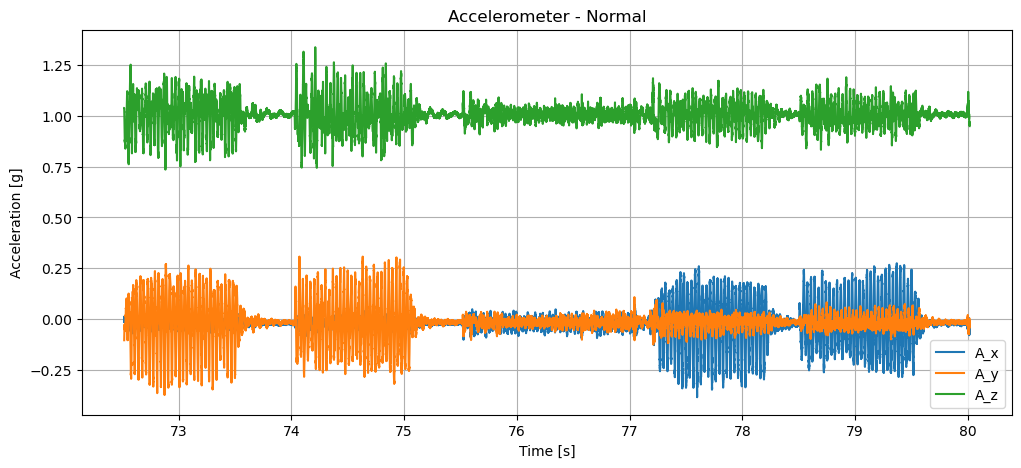

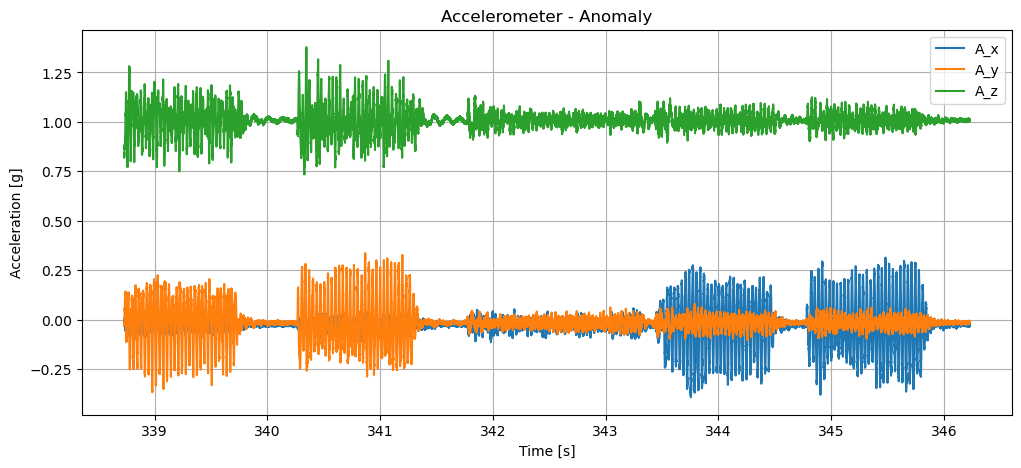

In [47]:
# wczytujemy dane z sensora akcelerometru dla wybranych segmentów normalnego i anormalnego zachowania maszyny

normal_acc = load_sensor(normal_segment_id, "acc", TEST_DIR)
anomaly_acc = load_sensor(anomaly_segment_id, "acc", TEST_DIR)

plt.figure(figsize=(12, 5))

plt.plot(normal_acc["Time"], normal_acc["A_x [g]"], label="A_x")
plt.plot(normal_acc["Time"], normal_acc["A_y [g]"], label="A_y")
plt.plot(normal_acc["Time"], normal_acc["A_z [g]"], label="A_z")

plt.title("Accelerometer - Normal")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(12, 5))

plt.plot(anomaly_acc["Time"], anomaly_acc["A_x [g]"], label="A_x")
plt.plot(anomaly_acc["Time"], anomaly_acc["A_y [g]"], label="A_y")
plt.plot(anomaly_acc["Time"], anomaly_acc["A_z [g]"], label="A_z")
plt.title("Accelerometer - Anomaly")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.legend()
plt.grid()
plt.show()

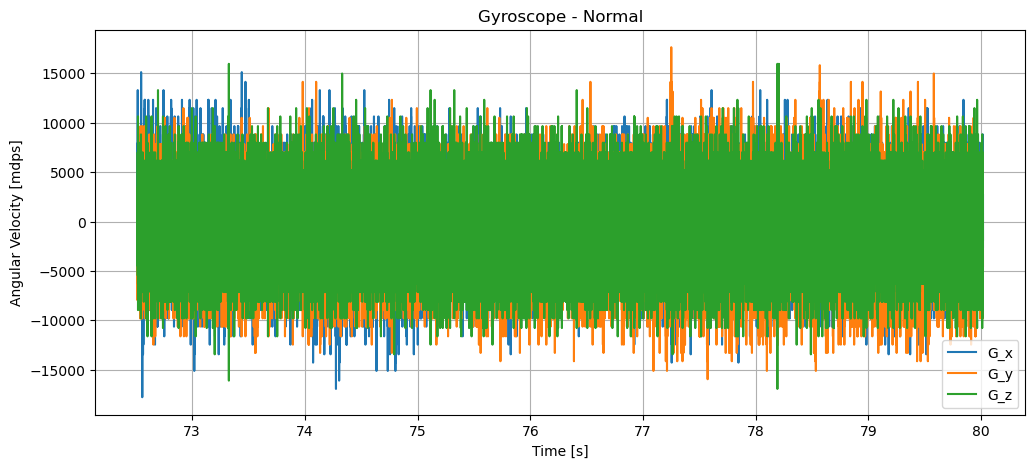

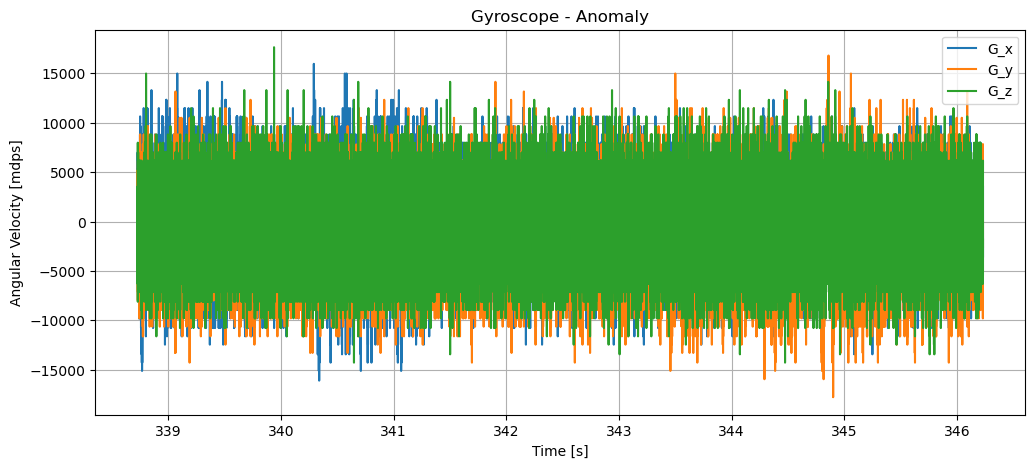

In [48]:
# wczytujemy dane z sensora żyroskopu dla wybranych segmentów normalnego i anormalnego zachowania maszyny
normal_gyro = load_sensor(normal_segment_id, "gyro", TEST_DIR)
anomaly_gyro = load_sensor(anomaly_segment_id, "gyro", TEST_DIR)


plt.figure(figsize=(12, 5))

plt.plot(normal_gyro["Time"], normal_gyro["G_x [mdps]"], label="G_x")
plt.plot(normal_gyro["Time"], normal_gyro["G_y [mdps]"], label="G_y")
plt.plot(normal_gyro["Time"], normal_gyro["G_z [mdps]"], label="G_z")

plt.title("Gyroscope - Normal")
plt.xlabel("Time [s]")
plt.ylabel("Angular Velocity [mdps]")
plt.legend()
plt.grid()


plt.figure(figsize=(12, 5))

plt.plot(anomaly_gyro["Time"], anomaly_gyro["G_x [mdps]"], label="G_x")
plt.plot(anomaly_gyro["Time"], anomaly_gyro["G_y [mdps]"], label="G_y")
plt.plot(anomaly_gyro["Time"], anomaly_gyro["G_z [mdps]"], label="G_z")

plt.title("Gyroscope - Anomaly")
plt.xlabel("Time [s]")
plt.ylabel("Angular Velocity [mdps]")
plt.legend()
plt.grid()

plt.show()

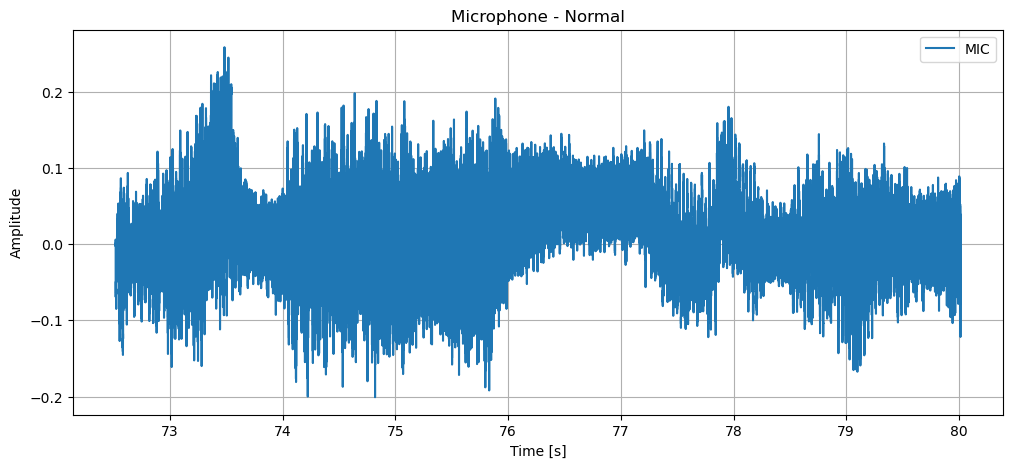

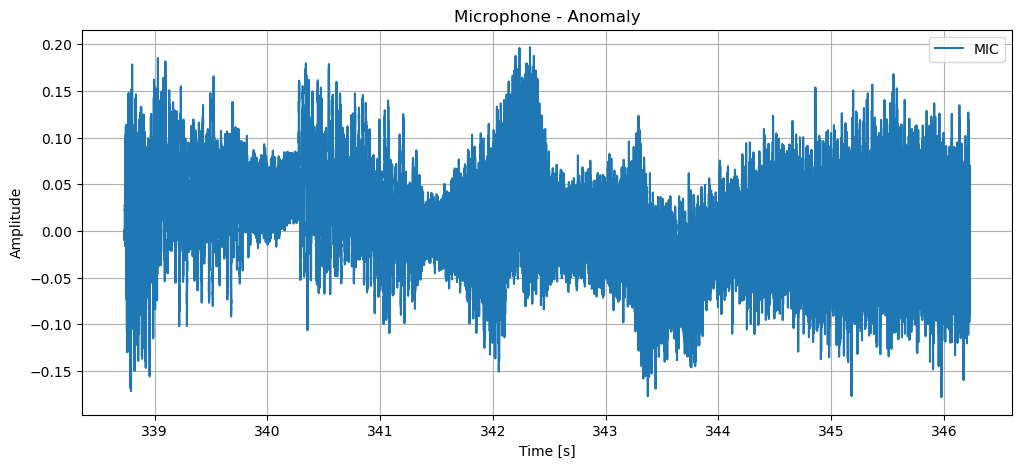

In [49]:
# wczytujemy dane z sensora mikrofonu dla wybranych segmentów normalnego i anormalnego zachowania maszyny

normal_mic = load_sensor(normal_segment_id, "mic", TEST_DIR)
anomaly_mic = load_sensor(anomaly_segment_id, "mic", TEST_DIR)

plt.figure(figsize=(12, 5))

plt.plot(normal_mic["Time"], normal_mic["MIC [Waveform]"], label="MIC")
plt.title("Microphone - Normal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()


plt.figure(figsize=(12, 5))

plt.plot(anomaly_mic["Time"], anomaly_mic["MIC [Waveform]"], label="MIC")
plt.title("Microphone - Anomaly")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.show()

na podstawie samych wykresów nie można jednoznacznie odróżnić normalnego i anomalnego zachowania maszyny